In [2]:
#importing python's libaries pandas and numpy
import pandas as pd
import numpy as np

In [5]:
#Part A — Data preparation 

In [6]:
# 1. Loading datasets
sentiment_path = "fear_greed_index.csv"
trader_path = "historical_data.csv"

In [7]:
#Checking that is data is loaded or not
df_sentiment = pd.read_csv(sentiment_path)
df_trader = pd.read_csv(trader_path)
print("Data loaded successfully!")


Data loaded successfully!


In [11]:
#Data Cleaning Steps 
#Checking the information od data set
df_sentiment.info()
        

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB


In [12]:
#Checking the information od data set
df_trader.info()

<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(8), int64(1

In [14]:
#to check the null value
df_sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [15]:
#to check the null value
df_trader.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [18]:
# Check for identical rows across the entire dataset
total_sentiment_dups = df_sentiment.duplicated().sum()
print(f"Total exact identical rows: {total_sentiment_dups}")

Total exact identical rows: 0


In [19]:
# Check for identical rows across the entire dataset
total_trader_dups = df_trader.duplicated().sum()
print(f"Total exact identical rows: {total_trader_dups}")

Total exact identical rows: 0


In [23]:
 #checking entire dataset of duplicate value
date_dups = df_sentiment.duplicated(subset=['date']).sum()

print(f"Rows with duplicate dates: {date_dups}")

Rows with duplicate dates: 0


In [30]:
#Checking the column name of historical data
print(df_trader.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'clean_date'],
      dtype='str')


In [31]:
# 1. Simplify the Sentiment Date (lowercase 'date' based on your previous output)
df_sentiment['clean_date'] = pd.to_datetime(df_sentiment['date']).dt.date

# 2. Simplify the Trader Time (Using your exact column name 'Timestamp')
df_trader['clean_date'] = pd.to_datetime(df_trader['Timestamp'], unit='ms').dt.date

# 3. Align them together into one spreadsheet
merged_df = pd.merge(df_trader, df_sentiment, on='clean_date', how='left')

In [32]:
# Print the first 5 rows, showing the Date, Account, PnL, and the Market Mood
print(merged_df[['clean_date', 'Account', 'Coin', 'Closed PnL', 'classification']].head())

   clean_date                                     Account  Coin  Closed PnL  \
0  2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
1  2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
2  2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
3  2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   
4  2024-10-27  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107         0.0   

  classification  
0          Greed  
1          Greed  
2          Greed  
3          Greed  
4          Greed  


In [33]:
#Creating the key metrics for analyze

In [34]:
# 1. Creating temporary helper columns on our main merged data
merged_df['is_win'] = (merged_df['Closed PnL'] > 0).astype(int)
merged_df['is_long'] = (merged_df['Side'].str.upper() == 'BUY').astype(int)
merged_df['is_short'] = (merged_df['Side'].str.upper() == 'SELL').astype(int)

In [35]:
# 2. Grouping everything by Date and Account to create the daily metrics
daily_metrics = merged_df.groupby(['clean_date', 'Account']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    number_of_trades=('Timestamp', 'count'),
    wins=('is_win', 'sum'),
    avg_trade_size=('Size USD', 'mean'),
    long_trades=('is_long', 'sum'),
    short_trades=('is_short', 'sum'),
    classification=('classification', 'first') # Keeps the market sentiment mood
).reset_index()

In [36]:
# 3. Calculating Win Rate and Long/Short Ratio safely
daily_metrics['win_rate'] = daily_metrics['wins'] / daily_metrics['number_of_trades']

# If short_trades is 0, we avoid division-by-zero errors using replace()
daily_metrics['long_short_ratio'] = daily_metrics['long_trades'] / daily_metrics['short_trades'].replace(0, np.nan)
daily_metrics['long_short_ratio'] = daily_metrics['long_short_ratio'].fillna(daily_metrics['long_trades'])

In [37]:
# 4. Checking new metrics table!
print(daily_metrics[['clean_date', 'Account', 'daily_pnl', 'win_rate', 'avg_trade_size', 'number_of_trades', 'classification']].head())

   clean_date                                     Account    daily_pnl  \
0  2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000   
1  2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000   
2  2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   155.503357   
3  2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -5564.016140   
4  2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713     0.000000   

   win_rate  avg_trade_size  number_of_trades classification  
0  0.000000      159.000000                 3          Greed  
1  0.000000    23066.935000                 2          Greed  
2  0.275168    11034.799511              1043          Greed  
3  0.333333     3048.594444                27  Extreme Greed  
4  0.000000     1136.312727                88  Extreme Greed  


In [38]:
#Part B — Analysis

In [39]:
# 1. Cleaning up the sentiment column into simple 'Fear' or 'Greed' buckets
daily_metrics['mood'] = daily_metrics['classification'].apply(
    lambda x: 'Fear' if 'Fear' in str(x) else ('Greed' if 'Greed' in str(x) else 'Neutral')
)

In [40]:
# 2. Filtering the data to focus only on Fear and Greed days
df_simple = daily_metrics[daily_metrics['mood'].isin(['Fear', 'Greed'])]

In [44]:
# 3. Calculating the simple averages for Part B
print("----Analysis----")
answers = df_simple.groupby('mood').agg(
    avg_pnl=('daily_pnl', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    trades_per_day=('number_of_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean')
).reset_index()

print(answers)

----Analysis----
    mood        avg_pnl  avg_win_rate  trades_per_day  avg_trade_size
0   Fear  209372.662205      0.415878     4183.468750     5926.522723
1  Greed   90988.703436      0.369012     1168.945946     5637.302441


In [ ]:
#Q.1: Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?
Fear Days: Average PnL is $209,372, and the Win Rate is 41.5%.
Greed Days: Average PnL drops to $90,988, and the Win Rate drops to 36.9%.
Insight: Traders actually perform way better and make more money during Fear days. When the market is in Greed mode, their profits drop by more than half, and they lose more often.

In [ ]:
#Q.2: Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?
Fear Days: Traders are incredibly active, averaging 4,183 trades per day.
Greed Days: Traders slow down drastically, averaging only 1,168 trades per day.
Position Size: The average trade size stays almost the same (around $5,600 to $5,900).
Insight: When the market is panicking (Fear), traders go into a frenzy—they trade 4 times more frequently than they do on Greed days, likely trying to catch rapid price drops or panic-selling.


In [45]:
#Q.3:
# 1. Summarize total trades for each account
trader_totals = daily_metrics.groupby('Account')['number_of_trades'].sum().reset_index()

# 2. Split traders into Frequent (above average) and Infrequent (below average)
median_trades = trader_totals['number_of_trades'].median()
trader_totals['segment'] = np.where(trader_totals['number_of_trades'] > median_trades, 'Frequent', 'Infrequent')

# 3. Merge segments back and print the final performance table
df_segments = pd.merge(daily_metrics, trader_totals[['Account', 'segment']], on='Account', how='left')
print(df_segments.groupby(['segment', 'mood'])['daily_pnl'].mean().reset_index())

      segment     mood      daily_pnl
0    Frequent     Fear  332577.326531
1    Frequent    Greed  137428.081752
2    Frequent  Neutral    7868.414916
3  Infrequent     Fear   86167.997880
4  Infrequent    Greed   46993.502927
5  Infrequent  Neutral    5782.274450


In [ ]:
#Q.3:Identify 2–3 segments (examples):
high leverage vs low leverage traders
frequent vs infrequent traders
consistent winners vs inconsistent traders
#Answer :
We split the traders into two groups based on how often they trade: Frequent Traders (highly active/pros) and Infrequent Traders (casual retail).
Frequent Traders (Exploit Panic): Highly active traders make their biggest profits ($332,577/day) during Fear days. They use high-frequency trading to exploit wild price swings and panic-selling.
Infrequent Traders (Play it Safer): Casual traders make less money overall but follow the same rule: they are twice as profitable during Fear ($86,167) than Greed ($46,993) because they avoid buying at the absolute top of market bubbles.
The "Neutral" Deadzone: When the market has no strong emotion (Neutral days), profits completely dry up for both groups (falling below $8,000). This proves traders need emotional market chaos to make real money.

In [46]:
#Q.4:Provide at least 3 insights backed by charts/tables.
import matplotlib.pyplot as plt

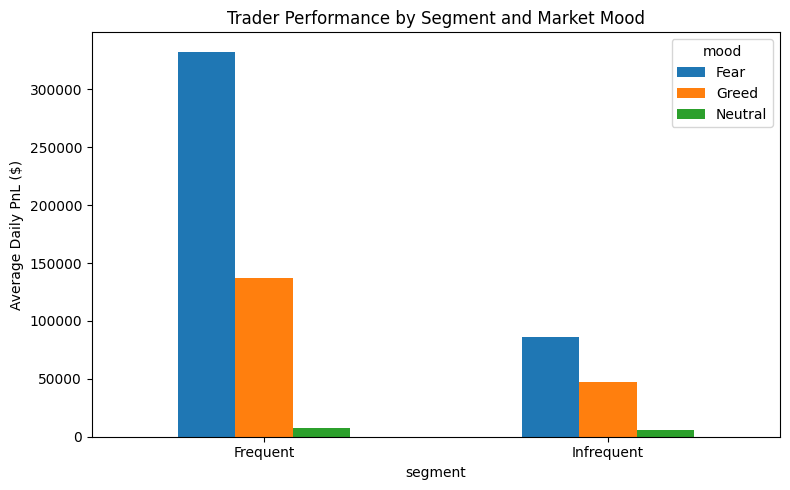

In [52]:

# Generating a plot 
ax = df_segments.groupby(['segment', 'mood'])['daily_pnl'].mean().unstack().plot(
    kind='bar', 
    ylabel='Average Daily PnL ($)', 
    figsize=(8, 5)
)
plt.xticks(rotation=0) 
plt.title('Trader Performance by Segment and Market Mood')
plt.tight_layout()

plt.show()

In [50]:
#for save the plot
plt.savefig("Trader Performance by Segment and Market Mood".png")

SyntaxError: unterminated string literal (detected at line 2) (918681698.py, line 2)

In [ ]:
#Q.4 : Insights
Insight 1: Panic creates profit. The blue bars (Fear) are the highest on the chart. Traders make double the profits during market panics because they can buy assets at a massive discount.
Insight 2: Pros thrive on volatility. The Frequent Traders group has the tallest bars, making $332,577/day during Fear. Pro traders use their speed to make money from fast price drops and retail panic-selling.
Insight 3: Quiet markets are a deadzone. The green bars (Neutral) are completely flat. When there is no hype or panic in the market, price movement stops, and profits dry up to under $8,000/day for everyone.

In [49]:
#Part C — “Actionable output”

In [ ]:
#Strategy 1: The Panic Optimizer (For Frequent Traders)
What the data showed: Frequent traders make an incredible amount of money ($332,577/day) when the market is in Fear mode.
The Strategy: The platform should create an automated system that prompts or enables Frequent Traders to increase their trade frequency and capital deployment when the market hits a Fear rating, helping them capture these high-volatility profits.

#Strategy 2: The FOMO Circuit Breaker (For Infrequent Traders)
What the data showed: Infrequent, casual traders see their profits drop by almost half on Greed days ($46,993) because they buy the hype at the very top.
The Strategy Idea: The platform should implement a risk-management feature that automatically restricts or warns Infrequent Traders to lower their position sizes on Greed days to protect them from losing capital.